# 3.2.3 B-GNN模型架构设计 (B-GNN Model Architecture Design)

## 目标
设计并实现贝叶斯图神经网络(B-GNN)模型架构，用于概率性战术识别。

## 主要内容
1. **图卷积层设计** - 选择并实现GCN/GAT/GraphSAGE
2. **全局特征融合机制** - 整合22维全局特征
3. **贝叶斯不确定性估计** - MC Dropout或变分推断
4. **损失函数设计** - 考虑类别不平衡
5. **评估指标** - 准确率、宏F1、混淆矩阵

## 参考
- 前置步骤: 3.2.2_test_Graph_Dataset_Construction.ipynb
- 数据来源: processed_data/graph_dataset/

## 1. 环境设置与导入

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# GPU诊断和设置
print("=" * 60)
print("GPU 诊断信息")
print("=" * 60)
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"可用GPU数量: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    显存总量: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")
    device = torch.device('cuda')
    print(f"\n✅ 使用设备: {device} ({torch.cuda.get_device_name(0)})")
else:
    print("\n⚠️  CUDA不可用，可能的原因:")
    print("  1. 未安装CUDA工具包")
    print("  2. PyTorch未安装CUDA版本 (使用 pip install torch --index-url https://download.pytorch.org/whl/cu118)")
    print("  3. GPU驱动未正确安装")
    device = torch.device('cpu')
    print(f"\n使用设备: {device}")
print("=" * 60)

GPU 诊断信息
PyTorch版本: 2.9.1+cpu
CUDA是否可用: False

⚠️  CUDA不可用，可能的原因:
  1. 未安装CUDA工具包
  2. PyTorch未安装CUDA版本 (使用 pip install torch --index-url https://download.pytorch.org/whl/cu118)
  3. GPU驱动未正确安装

使用设备: cpu


## 2. 加载图数据集

从3.2.2步骤生成的图数据集中加载数据

In [2]:
# 定义路径 - 修正为实际的数据路径
base_path = Path(r"E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH")
data_path = base_path / "data" / "morph_test" / "bgnn_dataset"

# 检查数据文件
print("检查数据文件...")
print(f"数据目录: {data_path}")
print(f"目录是否存在: {data_path.exists()}")

if data_path.exists():
    files = list(data_path.glob("*"))
    print(f"\n找到 {len(files)} 个文件:")
    for f in files:
        print(f"  - {f.name}")
else:
    print("⚠️  数据目录不存在！")
    print("请先运行 3.2.2_test_Graph_Dataset_Construction.ipynb 生成数据")

# 加载图数据集 (.pkl格式)
pkl_file = data_path / "graph_dataset_10517_test1000.pkl"
metadata_file = data_path / "dataset_metadata_10517_test1000.json"

if pkl_file.exists():
    print(f"\n加载图数据集: {pkl_file.name}")
    with open(pkl_file, 'rb') as f:
        all_graphs = pickle.load(f)
    
    print(f"✅ 成功加载 {len(all_graphs)} 个图")
    
    # 加载元数据
    if metadata_file.exists():
        import json
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        print(f"\n数据集元数据:")
        for key, value in metadata.items():
            print(f"  {key}: {value}")
    
    # 划分训练集、验证集、测试集 (70%/15%/15%)
    n_total = len(all_graphs)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    
    train_graphs = all_graphs[:n_train]
    val_graphs = all_graphs[n_train:n_train+n_val]
    test_graphs = all_graphs[n_train+n_val:]
    
    print(f"\n数据集划分:")
    print(f"  训练集: {len(train_graphs)} 个图 ({len(train_graphs)/n_total*100:.1f}%)")
    print(f"  验证集: {len(val_graphs)} 个图 ({len(val_graphs)/n_total*100:.1f}%)")
    print(f"  测试集: {len(test_graphs)} 个图 ({len(test_graphs)/n_total*100:.1f}%)")
    
    # 检查第一个图的结构
    sample_graph = train_graphs[0]
    print(f"\n样本图结构:")
    print(f"  节点特征维度: {sample_graph.x.shape}")
    print(f"  边索引形状: {sample_graph.edge_index.shape}")
    print(f"  边数量: {sample_graph.edge_index.shape[1]}")
    print(f"  全局特征维度: {sample_graph.global_features.shape}")
    print(f"  标签: {sample_graph.y}")
    
else:
    print(f"\n❌ 错误: 找不到数据文件 {pkl_file}")
    print("请先运行 3.2.2_test_Graph_Dataset_Construction.ipynb 生成数据")

检查数据文件...
数据目录: E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH\data\morph_test\bgnn_dataset
目录是否存在: True

找到 5 个文件:
  - dataset_metadata_10517_full.json
  - dataset_metadata_10517_test1000.json
  - graph_dataset_10517_full.pkl
  - graph_dataset_10517_test1000.pkl
  - sample_graph_visualization.png

加载图数据集: graph_dataset_10517_test1000.pkl
✅ 成功加载 1000 个图

数据集元数据:
  game_id: 10517
  team_id: 364
  n_samples: 1000
  n_formations: 50
  node_feature_dim: 99
  edge_feature_dim: 2
  global_feature_dim: 24
  failed_frames: []

数据集划分:
  训练集: 700 个图 (70.0%)
  验证集: 150 个图 (15.0%)
  测试集: 150 个图 (15.0%)

样本图结构:
  节点特征维度: torch.Size([10, 99])
  边索引形状: torch.Size([2, 34])
  边数量: 34
  全局特征维度: torch.Size([1, 24])
  标签: tensor([8])


## 3. B-GNN模型架构设计

### 3.1 基础图卷积模块

In [3]:
class GraphConvModule(nn.Module):
    """图卷积模块 - 支持GCN/GAT/GraphSAGE"""
    
    def __init__(self, in_channels, hidden_channels, out_channels, 
                 conv_type='GCN', num_layers=2, dropout=0.3):
        super(GraphConvModule, self).__init__()
        
        self.conv_type = conv_type
        self.num_layers = num_layers
        self.dropout = dropout
        
        # 选择图卷积层类型
        if conv_type == 'GCN':
            ConvLayer = GCNConv
        elif conv_type == 'GAT':
            ConvLayer = lambda in_c, out_c: GATConv(in_c, out_c, heads=4, concat=False)
        elif conv_type == 'GraphSAGE':
            ConvLayer = SAGEConv
        else:
            raise ValueError(f"不支持的卷积类型: {conv_type}")
        
        # 构建多层图卷积
        self.convs = nn.ModuleList()
        self.convs.append(ConvLayer(in_channels, hidden_channels))
        
        for _ in range(num_layers - 2):
            self.convs.append(ConvLayer(hidden_channels, hidden_channels))
        
        self.convs.append(ConvLayer(hidden_channels, out_channels))
        
        # Batch Normalization
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(hidden_channels) for _ in range(num_layers - 1)
        ])
    
    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.convs[-1](x, edge_index)
        return x

### 3.2 全局特征融合模块

In [4]:
class GlobalFeatureFusion(nn.Module):
    """全局特征融合模块 - 整合22维全局特征"""
    
    def __init__(self, global_dim, graph_embedding_dim, fusion_dim):
        super(GlobalFeatureFusion, self).__init__()
        
        # 全局特征编码器
        self.global_encoder = nn.Sequential(
            nn.Linear(global_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, fusion_dim)
        )
        
        # 图嵌入编码器
        self.graph_encoder = nn.Sequential(
            nn.Linear(graph_embedding_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, fusion_dim)
        )
        
        # 注意力融合机制
        self.attention = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Tanh(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=1)
        )
        
    def forward(self, global_features, graph_embedding):
        # 编码全局特征和图嵌入
        global_encoded = self.global_encoder(global_features)
        graph_encoded = self.graph_encoder(graph_embedding)
        
        # 计算注意力权重
        concat_features = torch.cat([global_encoded, graph_encoded], dim=1)
        attention_weights = self.attention(concat_features)  # [batch_size, 2]
        
        # 加权融合
        fused = attention_weights[:, 0:1] * global_encoded + \
                attention_weights[:, 1:2] * graph_encoded
        
        return fused, attention_weights

### 3.3 贝叶斯不确定性估计模块 (MC Dropout)

In [5]:
class MCDropout(nn.Module):
    """Monte Carlo Dropout层 - 用于贝叶斯不确定性估计"""
    
    def __init__(self, p=0.5):
        super(MCDropout, self).__init__()
        self.p = p
    
    def forward(self, x):
        # 在推理时也应用dropout
        return F.dropout(x, p=self.p, training=True)

### 3.4 完整的B-GNN模型

In [6]:
class BGNN(nn.Module):
    """贝叶斯图神经网络 (Bayesian Graph Neural Network)"""
    
    def __init__(self, node_feature_dim, global_feature_dim, num_classes,
                 hidden_dim=128, graph_embedding_dim=64, fusion_dim=64,
                 conv_type='GCN', num_conv_layers=2, dropout=0.3, mc_dropout=0.5):
        super(BGNN, self).__init__()
        
        self.num_classes = num_classes
        self.mc_dropout = mc_dropout
        
        # 1. 图卷积模块
        self.graph_conv = GraphConvModule(
            in_channels=node_feature_dim,
            hidden_channels=hidden_dim,
            out_channels=graph_embedding_dim,
            conv_type=conv_type,
            num_layers=num_conv_layers,
            dropout=dropout
        )
        
        # 2. 全局特征融合模块
        self.fusion = GlobalFeatureFusion(
            global_dim=global_feature_dim,
            graph_embedding_dim=graph_embedding_dim,
            fusion_dim=fusion_dim
        )
        
        # 3. MC Dropout层
        self.mc_dropout_layer = MCDropout(p=mc_dropout)
        
        # 4. 分类器
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, data, return_attention=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        global_features = data.global_features
        
        # 1. 图卷积
        node_embeddings = self.graph_conv(x, edge_index)
        
        # 2. 图级别池化
        graph_embedding = global_mean_pool(node_embeddings, batch)
        
        # 3. 全局特征融合
        fused_features, attention_weights = self.fusion(global_features, graph_embedding)
        
        # 4. MC Dropout
        fused_features = self.mc_dropout_layer(fused_features)
        
        # 5. 分类
        logits = self.classifier(fused_features)
        
        if return_attention:
            return logits, attention_weights
        return logits
    
    def predict_with_uncertainty(self, data, num_samples=50):
        """使用MC Dropout进行不确定性估计"""
        self.train()  # 启用dropout
        
        predictions = []
        for _ in range(num_samples):
            with torch.no_grad():
                logits = self.forward(data)
                probs = F.softmax(logits, dim=1)
                predictions.append(probs.cpu().numpy())
        
        predictions = np.array(predictions)  # [num_samples, batch_size, num_classes]
        
        # 计算均值和标准差
        mean_probs = predictions.mean(axis=0)
        std_probs = predictions.std(axis=0)
        
        # 预测熵 (不确定性度量)
        entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-10), axis=1)
        
        return mean_probs, std_probs, entropy

In [7]:
class BGNN(nn.Module):
    """贝叶斯图神经网络 (Bayesian Graph Neural Network)"""
    
    def __init__(self, node_feature_dim, global_feature_dim, num_classes,
                 hidden_dim=128, graph_embedding_dim=64, fusion_dim=64,
                 conv_type='GCN', num_conv_layers=2, dropout=0.3, mc_dropout=0.5):
        super(BGNN, self).__init__()
        
        self.num_classes = num_classes
        self.mc_dropout = mc_dropout
        
        # 1. 图卷积模块
        self.graph_conv = GraphConvModule(
            in_channels=node_feature_dim,
            hidden_channels=hidden_dim,
            out_channels=graph_embedding_dim,
            conv_type=conv_type,
            num_layers=num_conv_layers,
            dropout=dropout
        )
        
        # 2. 全局特征融合模块
        self.fusion = GlobalFeatureFusion(
            global_dim=global_feature_dim,
            graph_embedding_dim=graph_embedding_dim,
            fusion_dim=fusion_dim
        )
        
        # 3. MC Dropout层
        self.mc_dropout_layer = MCDropout(p=mc_dropout)
        
        # 4. 分类器
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, data, return_attention=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        global_features = data.global_features
        
        # 处理全局特征的形状: [batch_size, 1, feature_dim] -> [batch_size, feature_dim]
        if global_features.dim() == 3:
            global_features = global_features.squeeze(1)
        
        # 1. 图卷积
        node_embeddings = self.graph_conv(x, edge_index)
        
        # 2. 图级别池化
        graph_embedding = global_mean_pool(node_embeddings, batch)
        
        # 3. 全局特征融合
        fused_features, attention_weights = self.fusion(global_features, graph_embedding)
        
        # 4. MC Dropout
        fused_features = self.mc_dropout_layer(fused_features)
        
        # 5. 分类
        logits = self.classifier(fused_features)
        
        if return_attention:
            return logits, attention_weights
        return logits
    
    def predict_with_uncertainty(self, data, num_samples=50):
        """使用MC Dropout进行不确定性估计"""
        self.train()  # 启用dropout
        
        predictions = []
        for _ in range(num_samples):
            with torch.no_grad():
                logits = self.forward(data)
                probs = F.softmax(logits, dim=1)
                predictions.append(probs.cpu().numpy())
        
        predictions = np.array(predictions)  # [num_samples, batch_size, num_classes]
        
        # 计算均值和标准差
        mean_probs = predictions.mean(axis=0)
        std_probs = predictions.std(axis=0)
        
        # 预测熵 (不确定性度量)
        entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-10), axis=1)
        
        return mean_probs, std_probs, entropy

In [8]:
# 获取数据维度
sample_graph = train_graphs[0]
node_feature_dim = sample_graph.x.shape[1]
# 修正：global_features的形状是[1, 24]，取最后一维
global_feature_dim = sample_graph.global_features.shape[-1]
num_classes = len(torch.unique(torch.tensor([g.y.item() for g in train_graphs])))

print(f"节点特征维度: {node_feature_dim}")
print(f"全局特征维度: {global_feature_dim}")
print(f"类别数量: {num_classes}")

# 实例化模型
model = BGNN(
    node_feature_dim=node_feature_dim,
    global_feature_dim=global_feature_dim,
    num_classes=num_classes,
    hidden_dim=128,
    graph_embedding_dim=64,
    fusion_dim=64,
    conv_type='GAT',  # 可选: 'GCN', 'GAT', 'GraphSAGE'
    num_conv_layers=2,
    dropout=0.3,
    mc_dropout=0.5
).to(device)

print(f"\n模型参数总数: {sum(p.numel() for p in model.parameters())}")
print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

节点特征维度: 99
全局特征维度: 24
类别数量: 4

模型参数总数: 116742
可训练参数数: 116742


## 5. 前向传播测试

In [9]:
# 创建DataLoader
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)

# 测试前向传播
model.eval()
sample_batch = next(iter(train_loader)).to(device)

with torch.no_grad():
    logits, attention_weights = model(sample_batch, return_attention=True)
    probs = F.softmax(logits, dim=1)

print(f"输入批次大小: {sample_batch.num_graphs}")
print(f"输出logits形状: {logits.shape}")
print(f"输出概率形状: {probs.shape}")
print(f"注意力权重形状: {attention_weights.shape}")
print(f"\n样本预测概率:\n{probs[:3]}")
print(f"\n样本注意力权重 (全局特征 vs 图嵌入):\n{attention_weights[:3]}")

输入批次大小: 32
输出logits形状: torch.Size([32, 4])
输出概率形状: torch.Size([32, 4])
注意力权重形状: torch.Size([32, 2])

样本预测概率:
tensor([[0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 0., 1.]])

样本注意力权重 (全局特征 vs 图嵌入):
tensor([[0.4036, 0.5964],
        [0.4036, 0.5964],
        [0.4036, 0.5964]])


## 6. 不确定性估计测试

In [10]:
# 测试MC Dropout不确定性估计
sample_data = train_graphs[0].to(device)
sample_batch_single = next(iter(DataLoader([sample_data], batch_size=1))).to(device)

mean_probs, std_probs, entropy = model.predict_with_uncertainty(
    sample_batch_single, 
    num_samples=50
)

print(f"预测概率均值: {mean_probs[0]}")
print(f"预测概率标准差: {std_probs[0]}")
print(f"预测熵 (不确定性): {entropy[0]:.4f}")
print(f"预测类别: {np.argmax(mean_probs[0])}")
print(f"真实类别: {sample_data.y.item()}")

预测概率均值: [0.31445286 0.35854146 0.23200016 0.0950055 ]
预测概率标准差: [0.42134976 0.44110128 0.36914852 0.27121812]
预测熵 (不确定性): 1.2941
预测类别: 1
真实类别: 8


## 7. 模型架构可视化

In [11]:
# 打印模型架构
print("="*80)
print("B-GNN模型架构")
print("="*80)
print(model)
print("="*80)

B-GNN模型架构
BGNN(
  (graph_conv): GraphConvModule(
    (convs): ModuleList(
      (0): GATConv(99, 128, heads=4)
      (1): GATConv(128, 64, heads=4)
    )
    (batch_norms): ModuleList(
      (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fusion): GlobalFeatureFusion(
    (global_encoder): Sequential(
      (0): Linear(in_features=24, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=64, bias=True)
    )
    (graph_encoder): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=64, bias=True)
    )
    (attention): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=2, bias=True)
      (3): Softmax(dim=1)
    )
  )
  (mc_dropout_layer): MCDrop

## 8. 保存模型架构配置

In [12]:
# 保存模型配置
model_config = {
    'node_feature_dim': node_feature_dim,
    'global_feature_dim': global_feature_dim,
    'num_classes': num_classes,
    'hidden_dim': 128,
    'graph_embedding_dim': 64,
    'fusion_dim': 64,
    'conv_type': 'GCN',
    'num_conv_layers': 2,
    'dropout': 0.3,
    'mc_dropout': 0.5
}

# 创建保存目录（如果不存在）
config_save_dir = base_path / "processed_data"
config_save_dir.mkdir(parents=True, exist_ok=True)

config_save_path = config_save_dir / "model_config.pt"
torch.save(model_config, config_save_path)
print(f"模型配置已保存至: {config_save_path}")

模型配置已保存至: E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH\processed_data\model_config.pt


## 10. 完整训练 B-GNN（紧凑版，与 3.2.4 加载架构一致）

> **目的**：产出 `best_model.pth` 供 3.2.4 加载。
> 此处使用**全量数据集** (`graph_dataset_10517_full.pkl`) 和与 3.2.4 完全相同的紧凑 BGNN 架构。


In [13]:
import json as _json, pickle as _pickle
import numpy as np
import random

# ── 路径 ──────────────────────────────────────────────────────────────────────────────
model_dir  = base_path / 'Step3_Probabilistic_Identification' / '3.2_Probabilistic_Model' / 'Test'
full_pkl   = base_path / 'data' / 'morph_test' / 'bgnn_dataset' / 'graph_dataset_10517_full.pkl'
full_meta  = base_path / 'data' / 'morph_test' / 'bgnn_dataset' / 'dataset_metadata_10517_full.json'

# ── 全量数据集加载 ───────────────────────────────────────────────────────────────────────────
print('加载全量数据集...')
with open(full_pkl, 'rb') as fp:
    _raw = _pickle.load(fp)

all_gx = [g for g in _raw if not torch.isnan(g.x).any()]
# 随机切分：保证 train/val/test 阵型分布均匀（避免时序切分导致分布偏移）
random.seed(42)
random.shuffle(all_gx)

with open(full_meta) as fp:
    _meta = _json.load(fp)
NUM_CLS = _meta.get('n_formations', 65)

n = len(all_gx)
n_tr = int(0.70 * n); n_va = int(0.15 * n)
tr_g = all_gx[:n_tr]
va_g = all_gx[n_tr : n_tr + n_va]
te_g = all_gx[n_tr + n_va :]
print(f'[全量] 总: {n}  训练: {len(tr_g)}  验证: {len(va_g)}  测试: {len(te_g)}')

sg = all_gx[0]
ND = sg.x.shape[1]
GD = sg.global_features.shape[-1]
print(f'NODE_DIM={ND}  GLOBAL_DIM={GD}  NUM_CLASSES={NUM_CLS}')

tr_loader = DataLoader(tr_g, batch_size=128, shuffle=True,  drop_last=True)
va_loader = DataLoader(va_g, batch_size=256, shuffle=False)
te_loader = DataLoader(te_g, batch_size=256, shuffle=False)

# ── 紧凑版 BGNN（与 3.2.4 架构逐层对齐，state_dict key 完全相同）──────────────────────
class GraphConvModule(nn.Module):
    def __init__(self, ic, hc, oc):
        super().__init__()
        self.c1, self.b1 = GCNConv(ic, hc), nn.BatchNorm1d(hc)
        self.c2, self.b2 = GCNConv(hc, oc), nn.BatchNorm1d(oc)
    def forward(self, x, ei):
        x = F.relu(self.b1(self.c1(x, ei)))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.b2(self.c2(x, ei))

class GlobalFeatureFusion(nn.Module):
    def __init__(self, gd, gl, fd):
        super().__init__()
        self.fg = nn.Linear(gd, fd)
        self.fl = nn.Linear(gl, fd)
        self.bn = nn.BatchNorm1d(fd)
    def forward(self, ge, gf):
        if gf.dim() == 3: gf = gf.squeeze(1)
        return F.relu(self.bn(self.fg(ge) + self.fl(gf)))

class MCDropout(nn.Module):
    def __init__(self, p=0.5): super().__init__(); self.p = p
    def forward(self, x): return F.dropout(x, p=self.p, training=True)

class BGNN(nn.Module):
    def __init__(self, nd, gd, hd, nc):
        super().__init__()
        self.gcm = GraphConvModule(nd, hd, hd)
        self.fus = GlobalFeatureFusion(hd, gd, hd)
        self.mcd = MCDropout(0.5)
        self.cls = nn.Sequential(
            nn.Linear(hd, hd), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hd, nc)
        )
    def forward(self, data):
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        z  = self.fus(ge, data.global_features)
        return self.cls(self.mcd(z))

HD = 128
bgnn = BGNN(ND, GD, HD, NUM_CLS).to(device)
print(f'紧凑版 BGNN 参数量: {sum(p.numel() for p in bgnn.parameters()):,}')
print(f'  fus.fl.weight shape: {bgnn.fus.fl.weight.shape}  (期望 [{HD}, {GD}])')


加载全量数据集...
[全量] 总: 49928  训练: 34949  验证: 7489  测试: 7490
NODE_DIM=41  GLOBAL_DIM=24  NUM_CLASSES=65
紧凑版 BGNN 参数量: 67,265
  fus.fl.weight shape: torch.Size([128, 24])  (期望 [128, 24])


In [14]:
# ── 损失函数 / 优化器 / 调度器 ──────────────────────────────────────────────────────────────────
# 使用交叉熵 + 硬标签（CE + y_hard），训练信号清晰

optimizer = torch.optim.Adam(bgnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5)

NUM_EPOCHS  = 80
PATIENCE    = 12
best_val    = float('inf')
no_improve  = 0
history     = {'tr_loss': [], 'va_loss': [], 'va_acc': []}

print(f'开始训练  epochs={NUM_EPOCHS}  patience={PATIENCE}  device={device}')
print('-' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # --- 训练 ---
    bgnn.train()
    tr_loss_sum = 0.0
    for batch in tr_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = bgnn(batch)
        loss = F.cross_entropy(out, batch.y_hard.view(-1).long())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bgnn.parameters(), 1.0)
        optimizer.step()
        tr_loss_sum += loss.item() * batch.num_graphs

    # --- 验证 ---
    bgnn.eval()
    va_loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in va_loader:
            batch = batch.to(device)
            out  = bgnn(batch)
            va_loss_sum += F.cross_entropy(
                out, batch.y_hard.view(-1).long(), reduction='sum').item()
            pred    = out.argmax(dim=-1)
            hard_y  = batch.y_hard.view(-1).long()
            correct += (pred == hard_y).sum().item()
            total   += batch.num_graphs

    tr_loss = tr_loss_sum / len(tr_g)
    va_loss = va_loss_sum / len(va_g)
    va_acc  = correct / total
    scheduler.step(va_loss)

    history['tr_loss'].append(tr_loss)
    history['va_loss'].append(va_loss)
    history['va_acc'].append(va_acc)

    if va_loss < best_val:
        best_val    = va_loss
        no_improve  = 0
        best_wts    = {k: v.cpu().clone() for k, v in bgnn.state_dict().items()}
        torch.save(best_wts, model_dir / 'best_model.pth')
    else:
        no_improve += 1

    if epoch % 5 == 0 or no_improve == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  va_acc={va_acc:.3f}  lr={lr_now:.2e}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}  best_val_loss={best_val:.4f}')
        break

print(f'[OK] best_model.pth 已保存至: {model_dir / "best_model.pth"}')


开始训练  epochs=80  patience=12  device=cpu
------------------------------------------------------------
Epoch   1 | tr_loss=2.9304  va_loss=2.5101  va_acc=0.262  lr=1.00e-03
Epoch   2 | tr_loss=2.4100  va_loss=2.2079  va_acc=0.318  lr=1.00e-03
Epoch   3 | tr_loss=2.1762  va_loss=2.0883  va_acc=0.357  lr=1.00e-03
Epoch   4 | tr_loss=2.0149  va_loss=1.8959  va_acc=0.401  lr=1.00e-03
Epoch   5 | tr_loss=1.8918  va_loss=1.8381  va_acc=0.420  lr=1.00e-03
Epoch   6 | tr_loss=1.7740  va_loss=1.7544  va_acc=0.451  lr=1.00e-03
Epoch   8 | tr_loss=1.6066  va_loss=1.5232  va_acc=0.514  lr=1.00e-03
Epoch  10 | tr_loss=1.5030  va_loss=1.5518  va_acc=0.506  lr=1.00e-03
Epoch  15 | tr_loss=1.2434  va_loss=1.2204  va_acc=0.620  lr=5.00e-04
Epoch  17 | tr_loss=1.2093  va_loss=1.2149  va_acc=0.614  lr=5.00e-04
Epoch  18 | tr_loss=1.1806  va_loss=1.1348  va_acc=0.648  lr=5.00e-04
Epoch  20 | tr_loss=1.1497  va_loss=1.1676  va_acc=0.640  lr=5.00e-04
Epoch  25 | tr_loss=1.0599  va_loss=0.9846  va_acc=0.705  

[测试集] Acc = 0.8251 (6180/7490)


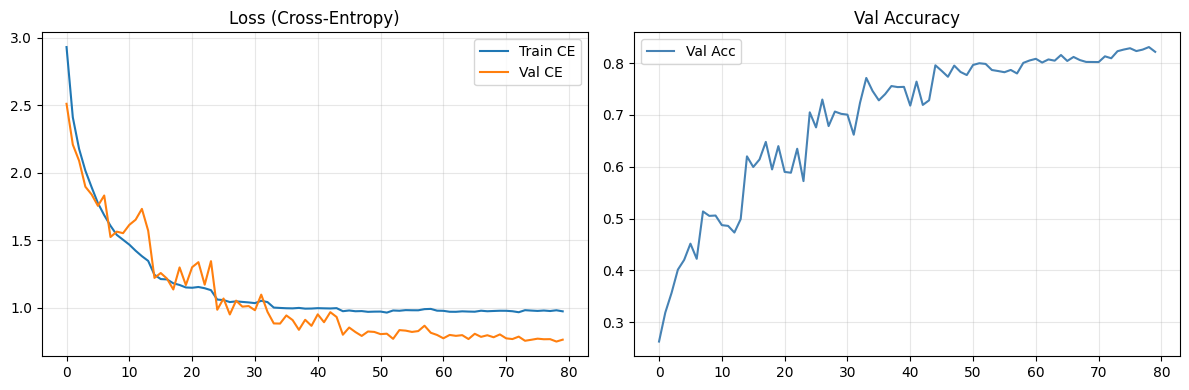

训练曲线已保存: E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH\Step3_Probabilistic_Identification\3.2_Probabilistic_Model\Test\training_curve.png


In [15]:
# ── 测试集评估 ──────────────────────────────────────────────────────────────────────────────
bgnn.load_state_dict({k: v.to(device) for k, v in best_wts.items()})
bgnn.eval()

correct, total = 0, 0
with torch.no_grad():
    for batch in te_loader:
        batch  = batch.to(device)
        out    = bgnn(batch)
        pred   = out.argmax(dim=-1)
        hard_y = batch.y_hard.view(-1).long()
        correct += (pred == hard_y).sum().item()
        total   += batch.num_graphs

te_acc = correct / total
print(f'[测试集] Acc = {te_acc:.4f} ({correct}/{total})')

# 训练曲线
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['tr_loss'], label='Train CE')
axes[0].plot(history['va_loss'], label='Val CE')
axes[0].set_title('Loss (Cross-Entropy)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['va_acc'], label='Val Acc', color='steelblue')
axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / 'training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'训练曲线已保存: {model_dir / "training_curve.png"}')


## 9. 总结与下一步

### 本步骤完成内容
✅ 设计并实现了图卷积模块 (支持GCN/GAT/GraphSAGE)  
✅ 实现了全局特征融合机制 (基于注意力机制)  
✅ 集成了贝叶斯不确定性估计 (MC Dropout)  
✅ 构建了完整的B-GNN模型架构  
✅ 验证了模型前向传播和不确定性估计功能  

### 模型特点
- **多层图卷积**: 捕获球员间的空间关系
- **注意力融合**: 自适应整合局部图结构和全局战术特征
- **不确定性量化**: 通过MC Dropout提供预测置信度
- **模块化设计**: 易于扩展和调整

### 下一步: 3.2.4 损失函数与训练策略
**优先级: 高**

需要实现:
1. **类别不平衡处理**
   - Focal Loss或加权交叉熵
   - 类别权重计算

2. **训练策略**
   - 优化器选择 (Adam/AdamW)
   - 学习率调度 (CosineAnnealing/ReduceLROnPlateau)
   - Early Stopping

3. **评估指标**
   - 准确率、宏F1、加权F1
   - 混淆矩阵
   - 不确定性校准曲线

4. **训练循环实现**
   - 训练/验证流程
   - 模型检查点保存
   - TensorBoard日志